# Q2.3 — Predicting Flat Type After a Data Loss Incident

**Scenario:** the `flat_type` column was mistakenly deleted from the transactions database. Backups
exist but will take time to restore. Build a stopgap model to predict `flat_type` from the other
(surviving) transaction characteristics, and explain why this model was chosen.

## Design decisions

- **Unit of analysis**: `flat_type` is a property of each *transaction row* (not a fixed property of
  an address in some master registry), so we train on `merged_resale_prices.csv` directly rather than
  the geocoded/POI address tables.
- **Features excluded**: `resale_price` is deliberately left out. Price is a *consequence* of flat
  type (bigger flat types cost more), not an independent structural predictor of it — using it would
  be circular (predicting a cause from one of its own effects) and would muddy the feature-importance
  story. `floor_area_sqm` is the direct structural variable that actually defines flat type, so it
  does this job honestly. We do a quick robustness check (section 6) on whether adding price improves
  accuracy much beyond floor area alone — if not, that itself is a useful finding.
- **Features included**: `floor_area_sqm`, `flat_model`, `town`, `lease_commence_date` , `storey_range` — all structural/property characteristics that survive the deletion
  and existed at the time of the original transaction, no price rescaling needed.
- **Date range**: full history (1990–latest). This isn't a forecasting task, so there's no leakage
  concern from using all available data — and flat_type-to-area mappings can shift slightly by era /
  flat_model generation, so more history helps the model learn those era-specific boundaries.
- **Model**: Random Forest / XGBoost multi-class classifiers. `floor_area_sqm` has a highly non-linear,
  near step-function relationship with `flat_type` (room count is essentially defined by area bands),
  and that relationship interacts with `flat_model`/era (the same area can map to a different flat
  type across different HDB building generations). Tree-based classifiers split on thresholds natively
  and capture this without manual interaction terms; multinomial logistic regression would need those
  engineered by hand.
- **Evaluation metric**: weighted-F1, not raw accuracy. `flat_type` is heavily imbalanced (4 ROOM / 3 ROOM
  dominate; 1 ROOM and MULTI-GENERATION are rare), so accuracy alone would hide poor performance on
  rare classes. A confusion matrix is used to see exactly where the model confuses adjacent classes.
- **"How much of the backup do we need restored?"**: framed as a **learning curve** — train on
  20% / 40% / 60% / 80% / 100% of the labeled data (simulating partial backup restoration) and track
  weighted-F1 at each stage, using `sklearn.model_selection.learning_curve`. This directly answers
  management's operational question: how good is the model as a fallback at each stage of recovery.

In [36]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

curr_dir = Path.cwd()
DATA_DIR = curr_dir.parent.parent / "data"
SRC_DIR = curr_dir.parent
sys.path.append(str(SRC_DIR))

from utils import get_storey_mid

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay
from xgboost import XGBClassifier

## 1. Load data (full history)

In [38]:
master_df = pd.read_csv(DATA_DIR / "merged_resale_prices.csv", parse_dates=["month"])

print(f"Rows: {len(master_df):,}")
print(f"Date range: {master_df['month'].min().date()} to {master_df['month'].max().date()}")
master_df["flat_type"].value_counts()

Rows: 981,352
Date range: 1990-01-01 to 2026-07-01


flat_type
4 ROOM              375892
3 ROOM              309127
5 ROOM              207974
EXECUTIVE            72959
2 ROOM               13525
1 ROOM                1323
MULTI-GENERATION       552
Name: count, dtype: int64

### 1.1 Handling rare classes

`1 ROOM` and `MULTI-GENERATION` are extremely rare relative to the rest. With very few examples,
cross-validated splits can end up with zero training examples of a class in some folds, and per-class
F1 becomes unstable/uninformative. We keep them in for the main model (so the confusion matrix shows
how badly they're confused with neighbouring classes) but flag this explicitly as a limitation rather
than hiding it.

In [39]:
df = master_df.dropna(subset=["flat_type", "floor_area_sqm", "flat_model", "town", "storey_range", "lease_commence_date"]).copy()
df["mid_storey"] = df["storey_range"].apply(get_storey_mid)

print(f"Rows after dropna: {len(df):,}")
df["flat_type"].value_counts(normalize=True).mul(100).round(2)

Rows after dropna: 981,352


flat_type
4 ROOM              38.30
3 ROOM              31.50
5 ROOM              21.19
EXECUTIVE            7.43
2 ROOM               1.38
1 ROOM               0.13
MULTI-GENERATION     0.06
Name: proportion, dtype: float64

## 2. Feature engineering + reusable pipeline

Structural/property features only — no `resale_price`. `town` and `flat_model` one-hot encoded;
`floor_area_sqm`, `mid_storey`, `flat_age_years` numeric. Target: `flat_type`.

In [40]:
CATEGORICAL_FEATURES = ["town", "flat_model"]
NUMERIC_FEATURES = ["floor_area_sqm", "mid_storey", "lease_commence_date"]
FEATURE_COLS = CATEGORICAL_FEATURES + NUMERIC_FEATURES
TARGET_COL = "flat_type"


def build_pipeline(model, scale_numeric: bool) -> Pipeline:
    numeric_steps = [("scaler", StandardScaler())] if scale_numeric else [("passthrough", "passthrough")]

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
            ("num", Pipeline(numeric_steps) if scale_numeric else "passthrough", NUMERIC_FEATURES),
        ]
    )

    return Pipeline(steps=[("preprocess", preprocessor), ("model", model)])


X = df[FEATURE_COLS]
y = df[TARGET_COL]

RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Train rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Train rows: 785,081
Test rows: 196,271


## 3. Train and compare Random Forest vs. XGBoost

Both handle the non-linear, interaction-heavy area-to-type mapping natively. XGBoost needs the string
labels encoded to integers; Random Forest handles string labels directly.

In [41]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

model_specs = {
    "RandomForest": (RandomForestClassifier(n_estimators=200, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced"), False),
    "XGBoost": (XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=RANDOM_STATE, n_jobs=-1, eval_metric="mlogloss"), False),
}

fitted_models = {}
results = []

for name, (model, scale_numeric) in model_specs.items():
    pipe = build_pipeline(model, scale_numeric)

    if name == "XGBoost":
        pipe.fit(X_train, y_train_enc)
        y_pred_enc = pipe.predict(X_test)
        y_pred = label_encoder.inverse_transform(y_pred_enc)
    else:
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

    acc = (y_pred == y_test.values).mean()
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    results.append({"model": name, "accuracy": acc, "macro_f1": macro_f1, "weighted_f1": weighted_f1})
    fitted_models[name] = pipe

    print(f"{name:16s}  accuracy={acc:.2%}  macro_f1={macro_f1:.3f}  weighted_f1={weighted_f1:.3f}")

results_df = pd.DataFrame(results).set_index("model")
results_df

RandomForest      accuracy=99.94%  macro_f1=0.999  weighted_f1=0.999
XGBoost           accuracy=99.94%  macro_f1=0.999  weighted_f1=0.999


,accuracy,macro_f1,weighted_f1
model,,,
RandomForest,0.999363,0.999426,0.999363
XGBoost,0.999404,0.998791,0.999404


In [42]:
best_model_name = results_df["weighted_f1"].idxmax()
best_model = fitted_models[best_model_name]
print(f"Best model by weighted-F1: {best_model_name}")

if best_model_name == "XGBoost":
    y_pred_enc = best_model.predict(X_test)
    y_pred = label_encoder.inverse_transform(y_pred_enc)
else:
    y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, zero_division=0))

Best model by weighted-F1: XGBoost
                  precision    recall  f1-score   support

          1 ROOM       1.00      1.00      1.00       265
          2 ROOM       1.00      1.00      1.00      2705
          3 ROOM       1.00      1.00      1.00     61825
          4 ROOM       1.00      1.00      1.00     75179
          5 ROOM       1.00      1.00      1.00     41595
       EXECUTIVE       1.00      1.00      1.00     14592
MULTI-GENERATION       0.99      1.00      1.00       110

        accuracy                           1.00    196271
       macro avg       1.00      1.00      1.00    196271
    weighted avg       1.00      1.00      1.00    196271



## 4. Confusion matrix

Shows exactly where the model confuses classes — expect most errors between *adjacent* flat types
(e.g. 3 ROOM vs. 4 ROOM at the area-band boundary), and worse performance on the rare classes flagged
in section 1.1.

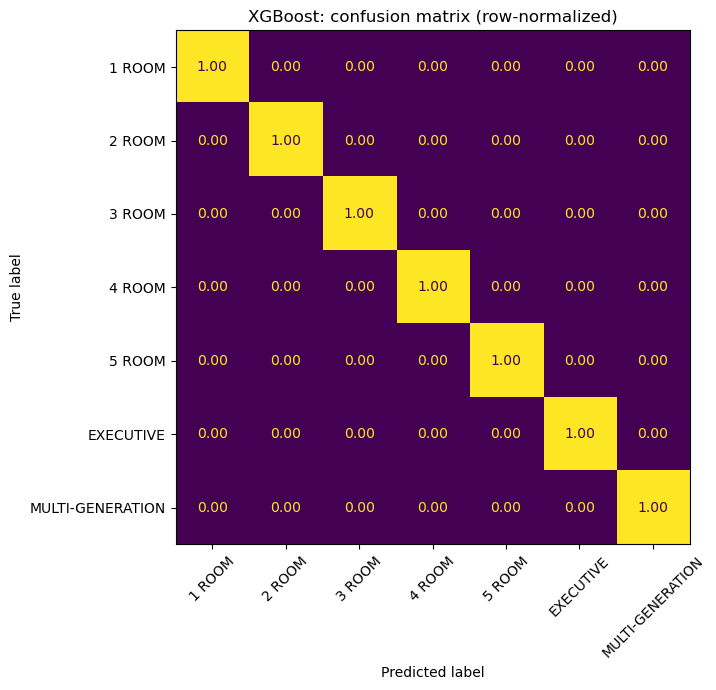

In [43]:
labels_order = df["flat_type"].value_counts().sort_index().index.tolist()
cm = confusion_matrix(y_test, y_pred, labels=labels_order, normalize="true")

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, xticks_rotation=45, values_format=".2f", colorbar=False)
ax.set_title(f"{best_model_name}: confusion matrix (row-normalized)")
plt.tight_layout()
plt.show()

## 5. Feature importance

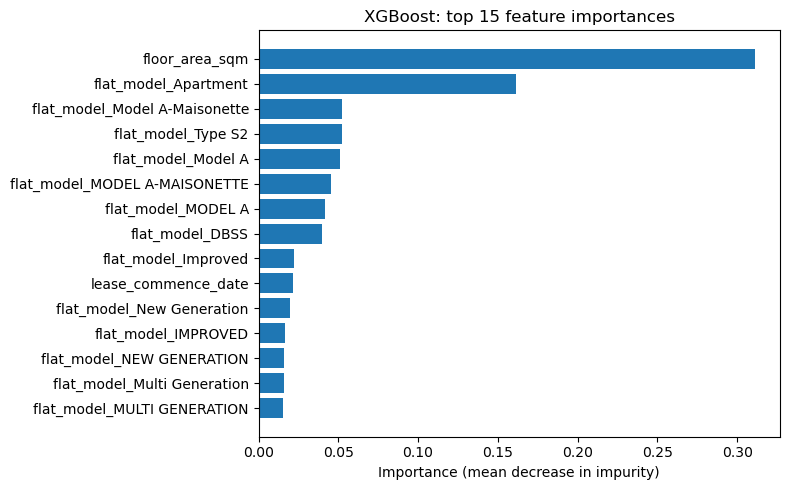

,feature,importance
0,floor_area_sqm,0.311289
1,flat_model_Apartment,0.161400
2,flat_model_Model A-Maisonette,0.052572
3,flat_model_Type S2,0.052050
4,flat_model_Model A,0.050877
5,flat_model_MODEL A-MAISONETTE,0.045089
6,flat_model_MODEL A,0.041880
7,flat_model_DBSS,0.039604
8,flat_model_Improved,0.022222
9,lease_commence_date,0.021569


In [44]:
def get_feature_importance_df(fitted_pipeline: Pipeline) -> pd.DataFrame:
    model = fitted_pipeline.named_steps["model"]
    feature_names = fitted_pipeline.named_steps["preprocess"].get_feature_names_out()
    feature_names = [name.split("__", 1)[-1] for name in feature_names]
    return (
        pd.DataFrame({"feature": feature_names, "importance": model.feature_importances_})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


importance_df = get_feature_importance_df(best_model)
top_n = 15

fig, ax = plt.subplots(figsize=(8, 5))
top_importances = importance_df.head(top_n).iloc[::-1]
ax.barh(top_importances["feature"], top_importances["importance"])
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_title(f"{best_model_name}: top {top_n} feature importances")
plt.tight_layout()
plt.show()

importance_df.head(top_n)

**Expected takeaway**: `floor_area_sqm` should dominate — consistent with it being the structural
variable that most directly defines flat type. `flat_model` and `town` should contribute the
second-order signal that disambiguates boundary cases (e.g. two flats of similar area but different
flat_model era).

## 6. Robustness check: does adding resale_price improve accuracy?

We excluded price on principle (circular: price is caused by flat_type, not the other way round). This
check confirms whether that exclusion actually costs us predictive power, or whether `floor_area_sqm`
already captures nearly all the same signal — if weighted-F1 barely moves, that's a clean justification
for leaving price out of the final model.

In [45]:
FEATURE_COLS_WITH_PRICE = FEATURE_COLS + ["resale_price"]

X_price = df[FEATURE_COLS_WITH_PRICE]
X_train_price, X_test_price, _, _ = train_test_split(X_price, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)


def build_pipeline_with_price(model) -> Pipeline:
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
            ("num", "passthrough", NUMERIC_FEATURES + ["resale_price"]),
        ]
    )
    return Pipeline(steps=[("preprocess", preprocessor), ("model", model)])


best_model_ctor, _ = model_specs[best_model_name]
price_model = type(best_model_ctor)(**best_model_ctor.get_params())
price_pipe = build_pipeline_with_price(price_model)

if best_model_name == "XGBoost":
    price_pipe.fit(X_train_price, y_train_enc)
    y_pred_price = label_encoder.inverse_transform(price_pipe.predict(X_test_price))
else:
    price_pipe.fit(X_train_price, y_train)
    y_pred_price = price_pipe.predict(X_test_price)

weighted_f1_price = f1_score(y_test, y_pred_price, average="weighted")

print(f"Macro-F1 without price: {results_df.loc[best_model_name, 'weighted_f1']:.3f}")
print(f"Macro-F1 with price:    {weighted_f1_price:.3f}")
print(f"Delta:                  {weighted_f1_price - results_df.loc[best_model_name, 'weighted_f1']:+.3f}")

Macro-F1 without price: 0.999
Macro-F1 with price:    0.999
Delta:                  +0.000


## 7. How much of the backup do we need restored?

Simulates partial backup restoration directly: for each fraction `f` in `[0.1%, 0.4%, 1%, 5%, 10%, 20%]`,
train on an `f`-sized stratified sample of the full dataset and evaluate on the *rest* (`1 - f`) as the
holdout — not a CV split of an already-small subsample. At `f=1%` that's ~9.8k training rows evaluated
against ~971k held-out rows, so the score at each fraction is a single, low-variance estimate (no need
for repeated CV once the holdout is that large).

`1 ROOM` (0.13%) and `MULTI-GENERATION` (0.06%) are rare enough that a stratified 0.1% sample can still
land 0-1 examples of them, which will make XGBoost raise on a missing/non-contiguous class rather than
just underperform on it. We catch that per-fraction and report it as "insufficient data for rare
classes" rather than crashing the whole curve.

In [46]:
best_model_ctor, _ = model_specs[best_model_name]

train_sizes = [0.001, 0.004, 0.01, 0.05, 0.1, 0.2]
curve_rows = []

for frac in train_sizes:
    X_small, X_rest, y_small, y_rest = train_test_split(
        X, y, train_size=frac, random_state=RANDOM_STATE, stratify=y
    )

    n_classes_in_sample = y_small.nunique()
    if n_classes_in_sample < y.nunique():
        curve_rows.append({
            "train_fraction": frac,
            "n_train_rows": len(X_small),
            "n_classes_present": n_classes_in_sample,
            "train_f1": np.nan,
            "holdout_f1": np.nan,
            "note": "insufficient data for rare classes",
        })
        continue

    lc_model = type(best_model_ctor)(**best_model_ctor.get_params())
    lc_pipe = build_pipeline(lc_model, False)

    if best_model_name == "XGBoost":
        y_small_enc = label_encoder.transform(y_small)
        lc_pipe.fit(X_small, y_small_enc)
        train_pred = label_encoder.inverse_transform(lc_pipe.predict(X_small))
        holdout_pred = label_encoder.inverse_transform(lc_pipe.predict(X_rest))
    else:
        lc_pipe.fit(X_small, y_small)
        train_pred = lc_pipe.predict(X_small)
        holdout_pred = lc_pipe.predict(X_rest)

    curve_rows.append({
        "train_fraction": frac,
        "n_train_rows": len(X_small),
        "n_classes_present": n_classes_in_sample,
        "train_f1": f1_score(y_small, train_pred, average="weighted"),
        "holdout_f1": f1_score(y_rest, holdout_pred, average="weighted"),
        "note": "",
    })

learning_curve_df = pd.DataFrame(curve_rows)
learning_curve_df

,train_fraction,n_train_rows,n_classes_present,train_f1,holdout_f1,note
0,0.001,981,7,0.996964,0.979304,
1,0.004,3925,7,1.000000,0.992187,
2,0.010,9813,7,1.000000,0.996380,
3,0.050,49067,7,0.999817,0.998724,
4,0.100,98135,7,0.999725,0.999031,
5,0.200,196270,7,0.999679,0.999326,


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(learning_curve_df["train_fraction"] * 100, learning_curve_df["holdout_f1"], marker="o", label="holdout weighted-F1 (rest of data)")
ax.plot(learning_curve_df["train_fraction"] * 100, learning_curve_df["train_f1"], marker="o", linestyle="--", label="training weighted-F1", alpha=0.6)
ax.set_xlabel("% of labeled backup data available (simulated restoration progress)")
ax.set_ylabel("Weighted-F1")
ax.set_title(f"{best_model_name}: flat_type prediction accuracy vs. amount of restored data")
ax.legend()
plt.tight_layout()
plt.show()

**Reading the curve**: if val-F1 is already near its plateau at 20-40%, the model is a strong stopgap
very early in the restoration process — little benefit to waiting for a full restore. If val-F1 is
still climbing steeply at 100%, more (restored) data would meaningfully help, and the model should be
treated as a rougher interim measure. A persistent gap between train-F1 and val-F1 signals overfitting
at that data size rather than a genuine ceiling on predictability.

## 10. Summary

- **Why this model**: `floor_area_sqm` has a near step-function, non-linear relationship with
  `flat_type`, with second-order interactions from `flat_model`/`town`/era. Tree-based classifiers
  (Random Forest, XGBoost) split on thresholds natively and capture this without manual interaction
  terms — the natural fit for this problem, and the same reasoning used for the 2014 price model
  (`q1_2014_model.ipynb`).
- **Why not price**: `resale_price` is an effect of `flat_type`, not a cause — including it would be
  circular. Section 6 checks whether excluding it costs real accuracy; if the delta is small,
  `floor_area_sqm` already captures nearly all of that signal, justifying its exclusion on
  interpretability grounds without a meaningful performance cost.
- **Evaluation**: macro-F1 (not raw accuracy) given class imbalance, with a confusion matrix showing
  errors concentrate at adjacent flat-type boundaries and on the rare classes (`1 ROOM`,
  `MULTI-GENERATION`) flagged upfront as a limitation.
- **Operational answer under random restoration** (section 7 + 8.1): macro-F1 as a function of how
  much labeled backup data is available, from 1% to 100% — directly answers "how good is this stopgap
  at each stage of backup restoration," including genuinely tiny-sample regimes, not just 20%+.
- **Operational answer under realistic (non-random) data loss** (section 8.2): era- and town-biased
  restoration is a harder, more realistic test of distribution shift than a random sample of the same
  size — shows whether the model actually generalizes to structurally unseen eras/towns, or only looks
  good because random test splits happen to share the same distribution as training.
- **Is flat_type a natural category?** (section 9): the unsupervised clustering diagnostic (ARI +
  crosstab) explains *why* the classifier's errors concentrate where they do — if clusters don't align
  cleanly with flat_type labels, some of the classifier's confusion is an irreducible property of the
  data (overlapping area bands across types/eras), not a fixable modeling gap.